## Initial baseline model

In [4]:
# Imports
import random
import os
import json
import re
from pathlib import Path
import tqdm
import cv2
from scipy import ndimage

import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.preprocess import *
from scripts.models import *


Processing: batch1_1.csv
Processing 499 images from ../finalproject_data/batch_1/batch1_1.csv
Images location: ../finalproject_data/batch_1/batch1_1


Processing batches: 100%|██████████| 10/10 [01:04<00:00,  6.47s/it]



Processing Complete!
Total images processed: 499
Successful: 499
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_2.csv
Processing 426 images from ../finalproject_data/batch_1/batch1_2.csv
Images location: ../finalproject_data/batch_1/batch1_2


Processing batches: 100%|██████████| 9/9 [00:55<00:00,  6.14s/it]



Processing Complete!
Total images processed: 426
Successful: 426
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_3.csv
Processing 489 images from ../finalproject_data/batch_1/batch1_3.csv
Images location: ../finalproject_data/batch_1/batch1_3


Processing batches: 100%|██████████| 10/10 [01:03<00:00,  6.33s/it]



Processing Complete!
Total images processed: 489
Successful: 489
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

FINAL SUMMARY
Total images across all batches: 1414
Successfully processed: 1414
Failed: 0

Visualizing sample results...


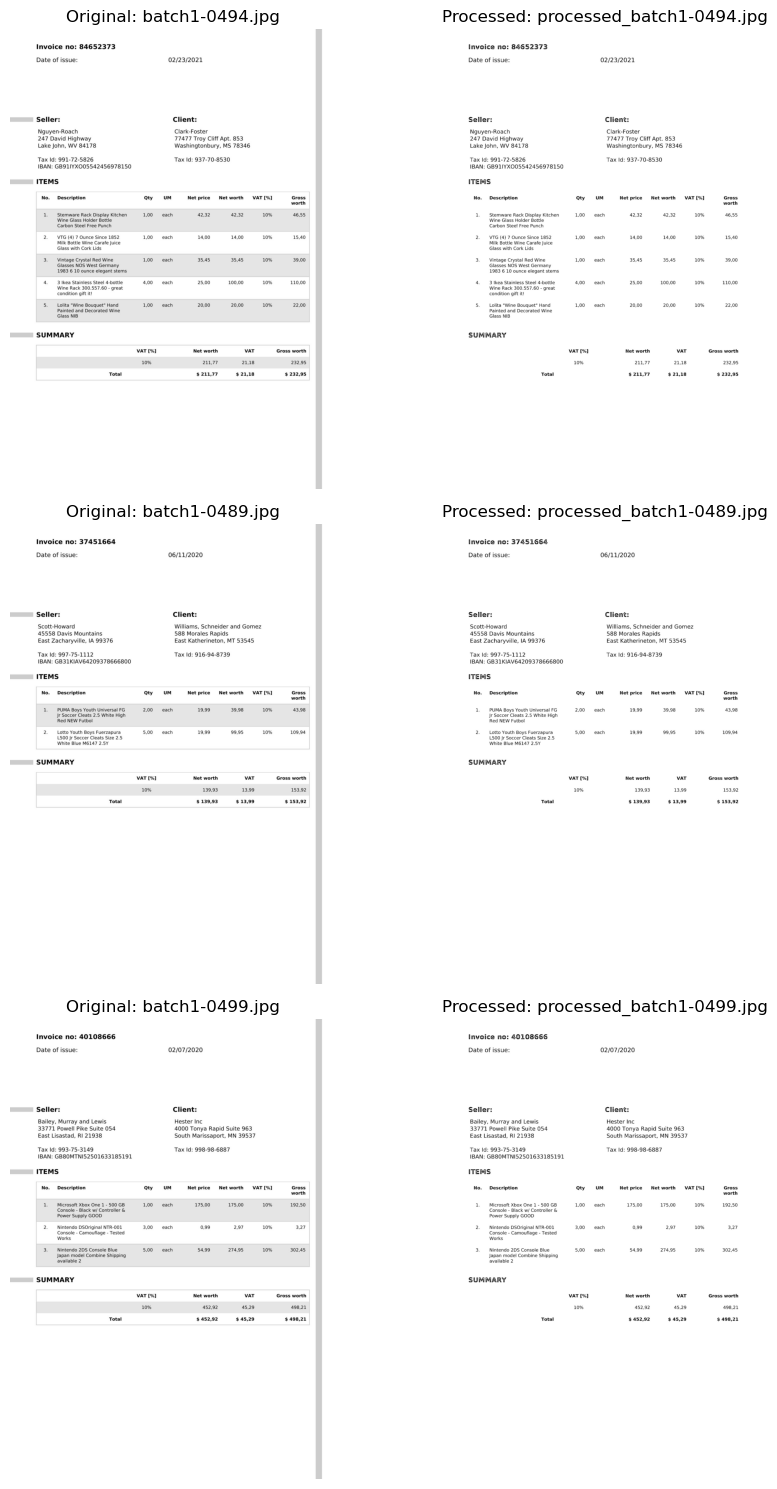

Processed images saved to: ../finalproject_data/processed_images


In [5]:
output_image_path = "../finalproject_data/processed_images"
csv_file_paths = [
    "../finalproject_data/batch_1/batch1_1.csv",
    "../finalproject_data/batch_1/batch1_2.csv",
    "../finalproject_data/batch_1/batch1_3.csv"
]

# Initialize preprocessor
preprocessor = InvoiceImagePreprocessor(output_dir=output_image_path)

image_folders = [
    '../finalproject_data/batch_1/batch1_1',
    '../finalproject_data/batch_1/batch1_2',
    '../finalproject_data/batch_1/batch1_3'
]

# Process all datasets
all_results = []
for csv_file, image_folder in zip(csv_file_paths, image_folders):
    print(f"\n{'='*80}")
    print(f"Processing: {Path(csv_file).name}")
    print(f"{'='*80}")
    
    results_df = preprocessor.process_images(csv_file, image_folder)
    all_results.append(results_df)

# Combine all results
if all_results:
    combined_results = pd.concat(all_results, ignore_index=True)
    
    print(f"\n{'='*80}")
    print("FINAL SUMMARY")
    print(f"{'='*80}")
    print(f"Total images across all batches: {len(combined_results)}")
    print(f"Successfully processed: {len(combined_results[combined_results['status'] == 'success'])}")
    print(f"Failed: {len(combined_results[combined_results['status'] == 'failed'])}")
    
    # Visualize sample results
    print("\nVisualizing sample results...")
    preprocessor.visualize_sample_results(combined_results)
    
    print(f"Processed images saved to: {output_image_path}")

In [6]:

ground_truth_df = pd.read_csv("../finalproject_data/cleaned_invoices.csv")
# Merge DFs to get processed image file paths
ground_truth_df = pd.merge(ground_truth_df, combined_results, left_on="File Name", right_on="original_file")
print(ground_truth_df.columns)
ground_truth_df.drop(columns=["File Name", "due_date"], inplace=True)

Index(['File Name', 'OCRed Text', 'batch_csv', 'client_name', 'seller_name',
       'invoice_number', 'invoice_date', 'due_date', 'tax', 'total_amount',
       'net_worth', 'original_file', 'processed_file', 'original_path',
       'processed_path', 'status'],
      dtype='str')


In [ ]:
# Initialize text detector
text_detector = InvoiceTextDetector(output_dir="../finalproject_data/output_images")

summary_df = text_detector.process_dataset(combined_results, sample_frac=0.1)

Processing 141 sampled images (10.0%)...


Processing OCR batches: 100%|██████████| 15/15 [02:02<00:00,  8.17s/it]


TEXT DETECTION SUMMARY
Total images processed: 141
Successful extractions: 141
Failed extractions: 0
Average words per image: 139.3
Average confidence: 93.8%

Extracted invoice fields:
  invoice_number: 141 images (100.0%)
  invoice_date: 141 images (100.0%)
  seller_name: 141 images (100.0%)
  client_name: 141 images (100.0%)
  tax: 120 images (85.1%)
  net_worth: 114 images (80.9%)
  total_amount: 120 images (85.1%)


In [8]:
metrics_df, overall = text_detector.evaluate_against_ground_truth(ground_truth_df)

print(metrics_df)
print("\nOverall:", overall)

Prediction rows: 141
Prediction unique keys: 141
Ground truth rows: 1414
Ground truth unique keys: 1413
Key overlap: 141
            field  ground_truth_count  predicted_count  correct  accuracy  \
0  invoice_number                 141              141      141  1.000000   
1    invoice_date                 141              141      141  1.000000   
2     seller_name                 141              141      141  1.000000   
3     client_name                 141              141      141  1.000000   
4       net_worth                 141              114      109  0.773050   
5    total_amount                 141              120      112  0.794326   
6             tax                 141              120      118  0.836879   

   precision    recall        f1  
0   1.000000  1.000000  1.000000  
1   1.000000  1.000000  1.000000  
2   1.000000  1.000000  1.000000  
3   1.000000  1.000000  1.000000  
4   0.956140  0.773050  0.854902  
5   0.933333  0.794326  0.858238  
6   0.983333  0.8

In [9]:
text_detector.debug_end_to_end(combined_results, ground_truth_df, n_samples=5)

Debugging 5 invoices

DEBUGGING FILE: processed_batch1-0858.jpg

OCR WORDS (204 words):
Invoice              | conf= 80 | bbox=(273, 155, 260, 51)
no:                  | conf= 95 | bbox=(567, 167, 106, 39)
59506452             | conf= 94 | bbox=(708, 155, 359, 51)
Date                 | conf= 96 | bbox=(273, 293, 138, 44)
of                   | conf= 96 | bbox=(437, 291, 57, 46)
issue:               | conf= 96 | bbox=(517, 291, 166, 46)
11/20/2017           | conf= 96 | bbox=(1613, 291, 340, 52)
Seller:              | conf= 96 | bbox=(271, 891, 234, 70)
Client:              | conf= 94 | bbox=(1657, 895, 236, 50)
Alexander,           | conf= 95 | bbox=(285, 1021, 294, 48)
Schneider            | conf= 96 | bbox=(605, 1021, 275, 42)
and                  | conf= 96 | bbox=(901, 1021, 96, 42)
Russo                | conf= 96 | bbox=(1025, 1023, 156, 40)
Graham-Martinez      | conf= 91 | bbox=(1673, 1021, 479, 42)
189                  | conf= 96 | bbox=(290, 1094, 97, 41)
Pearson             


Invoice Processing Analysis Dashboard

PROCESSING OVERVIEW
Total images processed: 141
Successful extractions: 141 (100.0%)
Failed extractions: 0 (0.0%)

OCR QUALITY METRICS
Average words per invoice: 139.3
Median words per invoice: 135
Word count range: 71 - 226
Average OCR confidence: 93.8%
Median OCR confidence: 94.0%
Confidence range: 91.9% - 94.8%

FIELD EXTRACTION SUCCESS RATES
  invoice_number : 100.0%
  invoice_date   : 100.0%
  seller_name    : 100.0%
  client_name    : 100.0%
  tax            :  85.1%
  net_worth      :  80.9%
  total_amount   :  85.1%

FIELD-LEVEL EXACT MATCH ACCURACIES
  invoice_number : 100.0%
  invoice_date   : 100.0%
  seller_name    : 100.0%
  client_name    : 100.0%
  tax            :  83.7%
  net_worth      :  77.3%
  total_amount   :  79.4%


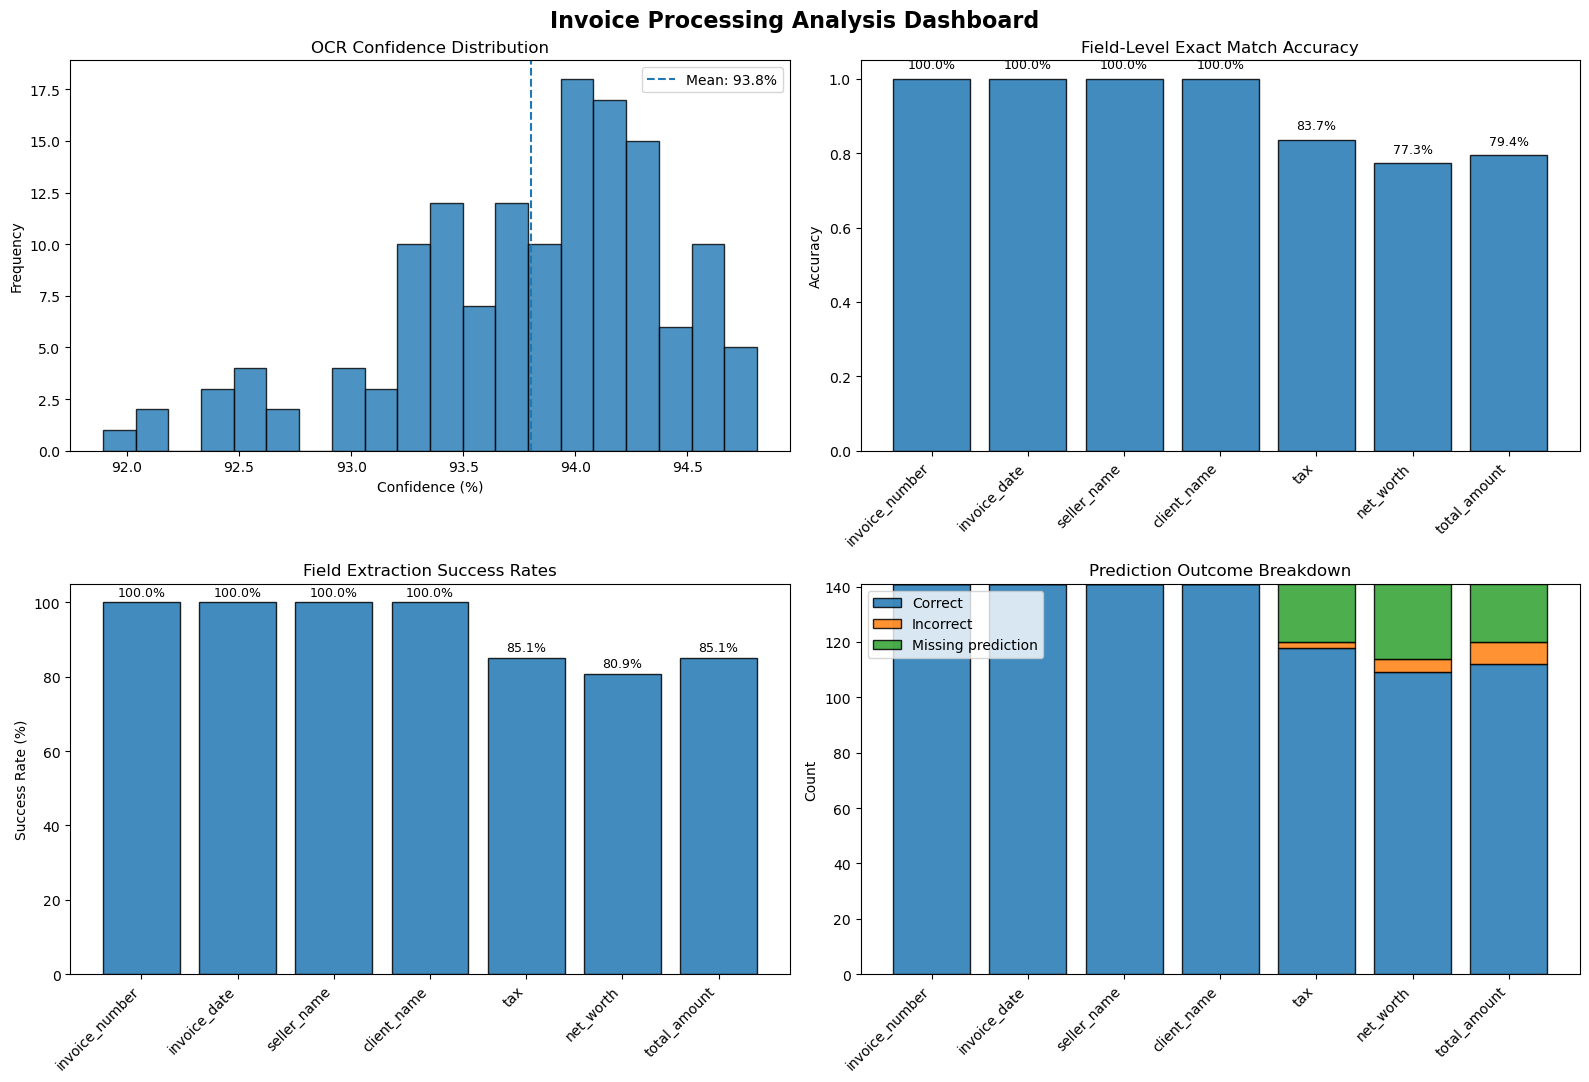


Sample 1: processed_batch1-0858.jpg
Total words detected: 204
Average confidence: 93.6%

Extracted Invoice Fields:
  invoice_number: 59506452
  invoice_date: 2017-11-20
  seller_name: Alexander, Schneider and Russo
  client_name: Graham-Martinez
  tax: 6156.30
  net_worth: 61563.04
  total_amount: 67719.34

Sample extracted text (first 10 words):
  Invoice no: 59506452 Date of issue: 11/20/2017 Seller: Client: Alexander,...


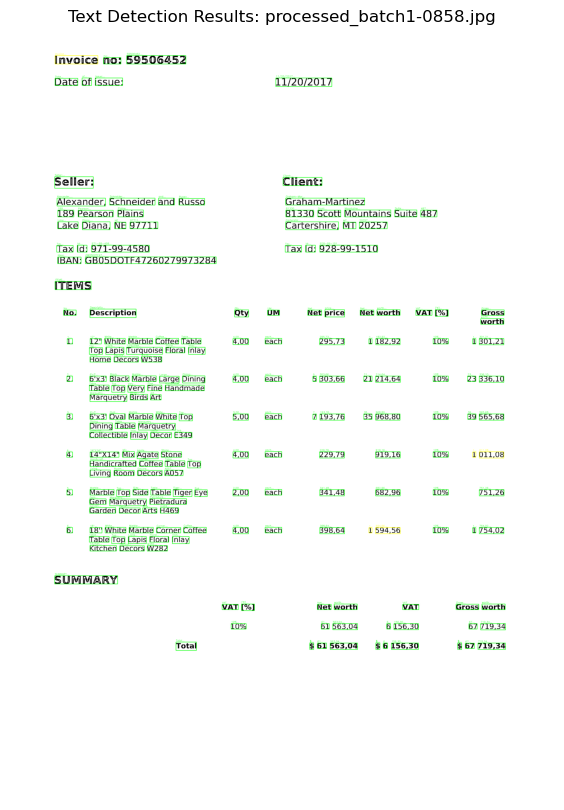


Extracted Invoice Fields:
  invoice_number: 59506452
  invoice_date: 2017-11-20
  seller_name: Alexander, Schneider and Russo
  client_name: Graham-Martinez
  tax: 6156.30
  net_worth: 61563.04
  total_amount: 67719.34

Sample 2: processed_batch1-0935.jpg
Total words detected: 124
Average confidence: 94.5%

Extracted Invoice Fields:
  invoice_number: 90172850
  invoice_date: 2012-09-22
  seller_name: Johnson, Johnson and Clark
  client_name: Morgan, Farmer and Cook
  tax: 6.54
  net_worth: 65.42
  total_amount: 71.96

Sample extracted text (first 10 words):
  Invoice no: 90172850 Date of issue: 09/22/2012 Seller: Client: Johnson,...


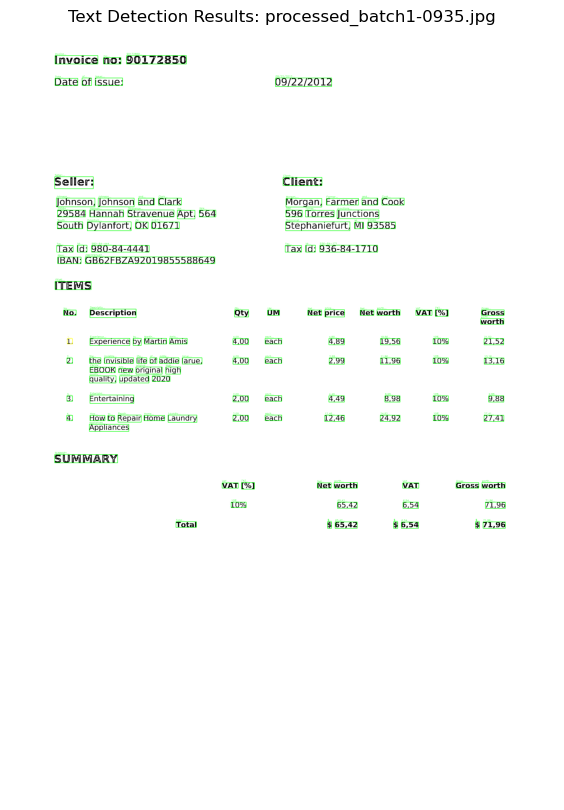


Extracted Invoice Fields:
  invoice_number: 90172850
  invoice_date: 2012-09-22
  seller_name: Johnson, Johnson and Clark
  client_name: Morgan, Farmer and Cook
  tax: 6.54
  net_worth: 65.42
  total_amount: 71.96

Sample 3: processed_batch1-0412.jpg
Total words detected: 116
Average confidence: 93.3%

Extracted Invoice Fields:
  invoice_number: 60866416
  invoice_date: 2021-02-17
  seller_name: Parker, Patterson and Smith
  client_name: Arnold PLC
  tax: 25.90
  net_worth: 258.96
  total_amount: 284.86

Sample extracted text (first 10 words):
  Invoice no: 60866416 Date of issue: 02/17/2021 Seller: Client: Parker,...


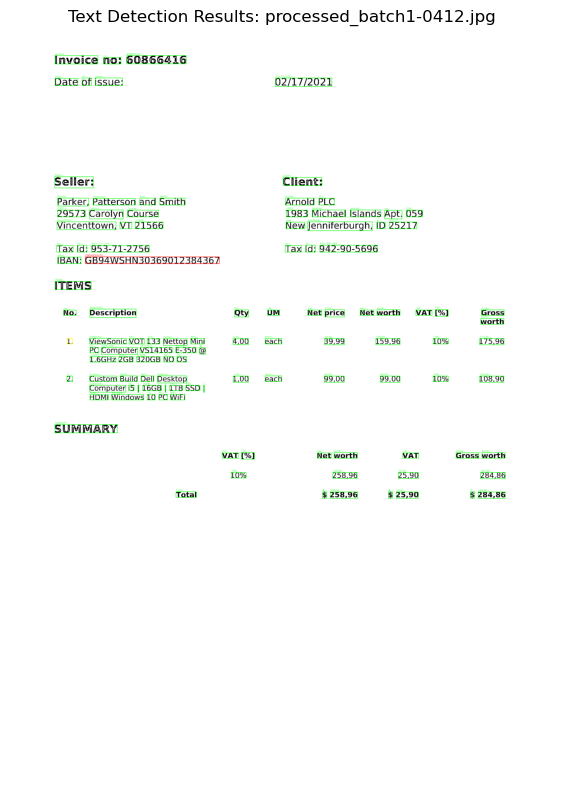


Extracted Invoice Fields:
  invoice_number: 60866416
  invoice_date: 2021-02-17
  seller_name: Parker, Patterson and Smith
  client_name: Arnold PLC
  tax: 25.90
  net_worth: 258.96
  total_amount: 284.86


In [10]:
dashboard_stats = create_analysis_dashboard(
    text_detector.full_results,
    metrics_df=metrics_df,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"]
)

visualize_sample_results(
    text_detector.full_results,
    visualize_text_fn=text_detector.visualize_text_extraction,
    n_samples=3
)